In [15]:
import os
from pathlib import Path

_cwd = Path.cwd()
if _cwd.name != 'notebooks':
    _nb_dir = _cwd / 'notebooks'
    if _nb_dir.is_dir():
        os.chdir(_nb_dir)

for _d in ['../outputs', '../data', '../models']:
    Path(_d).mkdir(exist_ok=True)

print(f'cwd: {Path.cwd()}')

cwd: c:\Users\adria\OneDrive\Desktop\Proyecto de machine learning\notebooks


# Fase 6 — Backtesting v3

Simulamos una estrategia de inversión usando las predicciones del modelo mejorado.

### Mejoras vs v2
- **23 features** (antes 16): EPS trend/zscore, momentum agreement, 5 features NLP del texto crudo
- **Target a 5 días**: captura el Post-Earnings Announcement Drift (PEAD), menos ruido
- **Ensemble XGBoost + LightGBM**: promedio de probabilidades de dos modelos independientes
- **Backtesting con retorno_5d**: alineado con el target que predice el modelo
- **Sharpe ratio**: métrica de riesgo-retorno además del capital final

### Estrategias
1. **Buy & Hold**: invertir en cada earnings call, holdear 5 días
2. **Long (umbral óptimo)**: solo cuando `prob_sube >= umbral`
3. **Long + Short**: long si `prob_sube >= umbral`, short si `prob_sube <= 1-umbral`

## 1. Importar librerías

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Cargar datos y modelo

In [17]:
df = pd.read_csv('../data/features.csv', parse_dates=['fecha_earnings'])

# Reproducir las mismas features derivadas inline que en notebook 05
df['eps_surprise_abs']    = df['eps_surprise_pct'].abs()
df['momentum_vol_ratio']  = df['momentum_5d'] / (df['volatility_20d'] + 0.01)
df['finbert_confidence']  = df[['score_positivo', 'score_negativo']].max(axis=1)
df['sent_momentum_align'] = (np.sign(df['polaridad']) == np.sign(df['momentum_5d'])).astype(int)

modelo_info    = joblib.load('../models/xgboost_model.pkl')
feature_cols   = modelo_info['feature_cols']
best_threshold = modelo_info['best_threshold']

X = df[feature_cols].values
y = df['target'].values

# Compatibilidad con modelo v2 (cv_f1_mean) y v3 (cv_f1_ensemble)
cv_f1_str = (
    f"Ensemble={modelo_info['cv_f1_ensemble']}  XGB={modelo_info['cv_f1_xgb']}  LGBM={modelo_info['cv_f1_lgbm']}"
    if 'cv_f1_ensemble' in modelo_info
    else f"(v2) {modelo_info.get('cv_f1_mean', 'n/a')}"
)
es_v3 = 'cv_f1_ensemble' in modelo_info

if not es_v3:
    print('⚠️  ATENCIÓN: el modelo cargado es la versión antigua (v2).')
    print('   Para usar el ensemble v3, ejecutá el notebook 05 primero y luego este.')
    print()

print(f'Datos: {df.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'CV F1: {cv_f1_str}')
print(f'Umbral óptimo:   {best_threshold}')
print(f'Target (5d>3%):  SUBE={y.sum()}, BAJA={len(y)-y.sum()}')

Datos: (228, 32)
Features (25): ['eps_surprise_pct', 'eps_surprise_abs', 'eps_surprise_trend', 'eps_surprise_zscore', 'momentum_5d', 'momentum_20d', 'volatility_20d', 'momentum_vol_ratio', 'momentum_agreement', 'score_positivo', 'score_negativo', 'score_neutral', 'polaridad', 'finbert_confidence', 'kw_positivos', 'kw_negativos', 'kw_ratio', 'kw_cat_enc', 'uncertainty_score', 'forward_guidance_score', 'text_length_log', 'question_density', 'negative_words_score', 'sent_momentum_align', 'tiene_transcripcion']
CV F1: Ensemble=0.4888  XGB=0.5066  LGBM=0.462
Umbral óptimo:   0.4
Target (5d>3%):  SUBE=89, BAJA=139


## 3. Predicciones out-of-sample (OOS)

`cross_val_predict` divide los datos en 5 folds y para cada fold devuelve las
probabilidades del modelo entrenado en los otros 4. Cada predicción fue hecha
por un modelo que **no vio ese dato al entrenar** — sin data leakage.

In [18]:
# Usamos las probabilidades OOS generadas en notebook 05 (ya sin data leakage)
prob_sube  = modelo_info['prob_oos']
pred_clase = (prob_sube >= best_threshold).astype(int)

df['prob_sube'] = prob_sube.round(3)
df['pred_sube'] = pred_clase == 1
df['correcto']  = pred_clase == y

df_sorted = df.sort_values('fecha_earnings').reset_index(drop=True)

print(f'Predicciones OOS del ensemble:')
print(f'  SUBE predichos: {pred_clase.sum()}  /  BAJA predichos: {(pred_clase==0).sum()}')
print(f'  Accuracy OOS:   {df["correcto"].mean():.3f}')
print(f'  (target basado en retorno_5d > 3%)')

Predicciones OOS del ensemble:
  SUBE predichos: 128  /  BAJA predichos: 100
  Accuracy OOS:   0.575
  (target basado en retorno_5d > 3%)


## 4. Estadísticas de la estrategia

In [19]:
apuestas    = df_sorted[df_sorted['pred_sube']]
no_apuestas = df_sorted[~df_sorted['pred_sube']]

win_rate             = apuestas['correcto'].mean()     if len(apuestas) > 0 else 0
retorno_prom_apuesta = apuestas['retorno_5d'].mean()   if len(apuestas) > 0 else 0
retorno_prom_bnh     = df_sorted['retorno_5d'].mean()

# Sharpe ratio (anualizado — ~48 earnings calls por año con 12 empresas)
n_per_year = 48
bets_per_year = n_per_year * (len(apuestas) / len(df_sorted))

ret_ap  = apuestas['retorno_5d'] / 100
ret_all = df_sorted['retorno_5d'] / 100

sharpe_long = (ret_ap.mean() / (ret_ap.std() + 1e-9)) * np.sqrt(bets_per_year)
sharpe_bnh  = (ret_all.mean() / (ret_all.std() + 1e-9)) * np.sqrt(n_per_year)

print('=== Estadísticas de la estrategia v3 ===')
print(f'Total earnings calls:         {len(df_sorted)}')
print(f'Operaciones (pred SUBE):       {len(apuestas)}')
print(f'Operaciones salteadas:         {len(no_apuestas)}')
print()
print(f'Win rate (target 5d>3%):      {win_rate:.1%}')
print(f'Retorno prom por apuesta (5d): {retorno_prom_apuesta:.2f}%')
print(f'Retorno prom B&H (5d):         {retorno_prom_bnh:.2f}%')
print()
print(f'Sharpe ratio Long-only:  {sharpe_long:.2f}')
print(f'Sharpe ratio Buy&Hold:   {sharpe_bnh:.2f}')

=== Estadísticas de la estrategia v3 ===
Total earnings calls:         228
Operaciones (pred SUBE):       128
Operaciones salteadas:         100

Win rate (target 5d>3%):      46.9%
Retorno prom por apuesta (5d): 2.20%
Retorno prom B&H (5d):         1.47%

Sharpe ratio Long-only:  1.02
Sharpe ratio Buy&Hold:   1.02


## 5. Retorno acumulado — Estrategia vs Buy & Hold

In [20]:
capital_inicial = 10_000

cap_bnh  = capital_inicial
cap_est  = capital_inicial
hist_bnh = [cap_bnh]
hist_est = [cap_est]

for _, row in df_sorted.iterrows():
    ret = row['retorno_5d'] / 100        # retorno a 5 días hábiles
    cap_bnh *= (1 + ret)
    if row['pred_sube']:
        cap_est *= (1 + ret)
    hist_bnh.append(round(cap_bnh, 2))
    hist_est.append(round(cap_est, 2))

print(f'Capital final Buy & Hold (5d):  ${cap_bnh:,.0f}  ({(cap_bnh/capital_inicial-1)*100:+.1f}%)')
print(f'Capital final Long-only  (5d):  ${cap_est:,.0f}  ({(cap_est/capital_inicial-1)*100:+.1f}%)')

Capital final Buy & Hold (5d):  $89,368  (+793.7%)
Capital final Long-only  (5d):  $71,575  (+615.8%)


## 6. Estrategia Long + Short

Cuando el modelo predice BAJA con alta confianza (`prob_sube <= 1 - umbral`),
hacemos **short**: ganamos cuando el precio baja.

In [21]:
cap_ls  = capital_inicial
hist_ls = [cap_ls]
n_long = n_short = n_cash = 0

for _, row in df_sorted.iterrows():
    ret = row['retorno_5d'] / 100        # retorno a 5 días hábiles
    if row['prob_sube'] >= best_threshold:
        cap_ls *= (1 + ret)
        n_long += 1
    elif row['prob_sube'] <= (1 - best_threshold):
        cap_ls *= (1 - ret)              # short: ganamos cuando baja
        n_short += 1
    else:
        n_cash += 1
    hist_ls.append(round(cap_ls, 2))

print(f'Operaciones — Long: {n_long}  Short: {n_short}  Cash: {n_cash}')
print(f'Capital Long-only  (5d): ${cap_est:,.0f}  ({(cap_est/capital_inicial-1)*100:+.1f}%)')
print(f'Capital Long+Short (5d): ${cap_ls:,.0f}   ({(cap_ls/capital_inicial-1)*100:+.1f}%)')
print(f'Capital Buy & Hold (5d): ${cap_bnh:,.0f}  ({(cap_bnh/capital_inicial-1)*100:+.1f}%)')

Operaciones — Long: 128  Short: 100  Cash: 0
Capital Long-only  (5d): $71,575  (+615.8%)
Capital Long+Short (5d): $30,177   (+201.8%)
Capital Buy & Hold (5d): $89,368  (+793.7%)


## 7. Gráfico — todas las estrategias

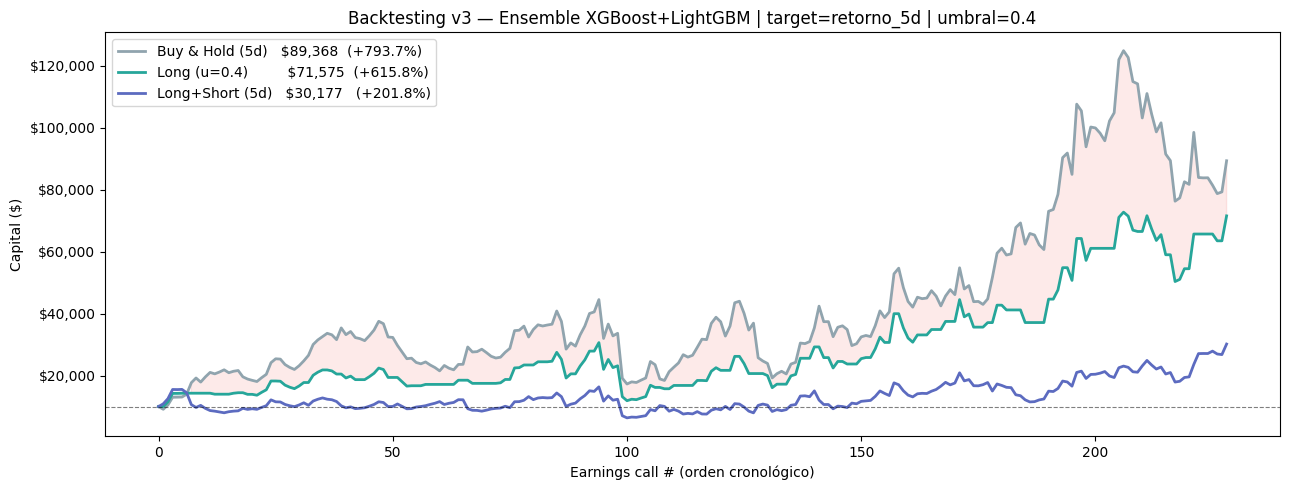

Guardado en outputs/backtesting.png


In [22]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(hist_bnh, label=f'Buy & Hold (5d)   ${cap_bnh:,.0f}  ({(cap_bnh/capital_inicial-1)*100:+.1f}%)',
        color='#90a4ae', linewidth=2)
ax.plot(hist_est, label=f'Long (u={best_threshold})         ${cap_est:,.0f}  ({(cap_est/capital_inicial-1)*100:+.1f}%)',
        color='#26a69a', linewidth=2)
ax.plot(hist_ls,  label=f'Long+Short (5d)   ${cap_ls:,.0f}   ({(cap_ls/capital_inicial-1)*100:+.1f}%)',
        color='#5c6bc0', linewidth=2)

ax.axhline(capital_inicial, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

ax.fill_between(range(len(hist_est)), hist_est, hist_bnh,
                where=[e > b for e, b in zip(hist_est, hist_bnh)],
                alpha=0.12, color='#26a69a')
ax.fill_between(range(len(hist_est)), hist_est, hist_bnh,
                where=[e <= b for e, b in zip(hist_est, hist_bnh)],
                alpha=0.12, color='#ef5350')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title(
    f'Backtesting v3 — Ensemble XGBoost+LightGBM | target=retorno_5d | umbral={best_threshold}',
    fontsize=12
)
ax.set_xlabel('Earnings call # (orden cronológico)')
ax.set_ylabel('Capital ($)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/backtesting.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado en outputs/backtesting.png')

## 8. Predicciones detalladas — test set

In [23]:
df_pred = df_sorted[['ticker', 'q', 'direccion', 'retorno_pct', 'retorno_5d',
                      'prob_sube', 'pred_sube', 'correcto']].copy()
df_pred['pred_label'] = df_pred['pred_sube'].map({True: 'SUBE', False: 'BAJA'})

print('Predicciones ordenadas por probabilidad (las más confiadas primero):')
print(df_pred[['ticker', 'q', 'retorno_pct', 'retorno_5d', 'prob_sube', 'pred_label', 'correcto']]
      .sort_values('prob_sube', ascending=False)
      .head(30)
      .to_string(index=False))

Predicciones ordenadas por probabilidad (las más confiadas primero):
ticker       q  retorno_pct  retorno_5d  prob_sube pred_label  correcto
  META 2024-Q3         7.46      2.9674      0.948       SUBE     False
  NFLX 2022-Q1       -22.94    -23.9154      0.945       SUBE     False
    MA 2020-Q4        -7.55      5.4293      0.928       SUBE      True
   AMD 2023-Q2        -1.86      7.2912      0.926       SUBE      True
  MSFT 2024-Q3        -1.96     -5.5117      0.907       SUBE     False
  NFLX 2023-Q4        12.95     18.7932      0.899       SUBE      True
    MA 2021-Q1         0.25      5.1036      0.898       SUBE      True
    MA 2021-Q4        -0.06      0.7207      0.887       SUBE     False
  META 2020-Q4        -1.70      4.9318      0.874       SUBE      True
  NVDA 2024-Q2         8.82     16.3770      0.873       SUBE      True
  NVDA 2019-Q3         6.32     15.2652      0.863       SUBE      True
  AMZN 2020-Q3         4.32      5.6726      0.861       SUBE      

## 9. Performance por empresa

In [24]:
def stats_ticker(grupo):
    ap = grupo[grupo['pred_sube']]
    return pd.Series({
        'calls':        len(grupo),
        'apuestas':     len(ap),
        'win_rate':     round(ap['correcto'].mean(), 2)    if len(ap) > 0 else None,
        'ret5d_prom':   round(ap['retorno_5d'].mean(), 2)  if len(ap) > 0 else None,
        'ret1d_prom':   round(ap['retorno_pct'].mean(), 2) if len(ap) > 0 else None,
    })

por_ticker = df_sorted.groupby('ticker').apply(stats_ticker)
print('=== Performance por empresa (retorno 5d) ===')
print(por_ticker.to_string())

=== Performance por empresa (retorno 5d) ===
        calls  apuestas  win_rate  ret5d_prom  ret1d_prom
ticker                                                   
AAPL     20.0       7.0      0.43        3.27        4.26
AMD      17.0      12.0      0.50        2.35        2.78
AMZN     19.0      12.0      0.58        1.44        1.50
GOOGL    19.0      14.0      0.43        0.47        1.30
JPM      17.0       8.0      0.25        0.74       -1.69
MA       17.0       7.0      0.71        4.42        1.43
META     19.0      14.0      0.50        3.24       -0.07
MSFT     20.0      11.0      0.45        1.31       -0.69
NFLX     19.0      11.0      0.36       -3.29       -5.43
NVDA     21.0      13.0      0.46        4.49        3.72
TSLA     21.0      13.0      0.46        5.35        2.04
V        19.0       6.0      0.50        2.95        0.34


## 10. Resumen final — v1 vs v2

In [25]:
n_empresas = df_sorted['ticker'].nunique()
anio_min   = df_sorted['fecha_earnings'].dt.year.min()
anio_max   = df_sorted['fecha_earnings'].dt.year.max()
version    = 'v3' if es_v3 else 'v2'

print(f'=== RESUMEN FINAL DEL PROYECTO ({version}) ===')
print(f'Dataset:    {len(df_sorted)} earnings calls, {n_empresas} empresas, {anio_min}-{anio_max}')
print(f'Features:   {len(feature_cols)}')
print(f'Modelo:     {"Ensemble XGBoost + LightGBM (soft voting)" if es_v3 else "XGBoost (scale_pos_weight)"}')
print(f'Target:     retorno_5d > 3% (PEAD)')
print(f'CV F1:      {cv_f1_str}')
print(f'Umbral:     {best_threshold}')
print()
print('--- Backtesting (retorno 5 días) ---')
print(f'Buy & Hold:     ${cap_bnh:,.0f}  ({(cap_bnh/capital_inicial-1)*100:+.1f}%)')
print(f'Long (u={best_threshold}):   ${cap_est:,.0f}  ({(cap_est/capital_inicial-1)*100:+.1f}%)')
print(f'Long + Short:   ${cap_ls:,.0f}   ({(cap_ls/capital_inicial-1)*100:+.1f}%)')
print(f'Win rate:       {win_rate:.1%}')
print(f'Sharpe Long:    {sharpe_long:.2f}')
print(f'Sharpe B&H:     {sharpe_bnh:.2f}')
print()
print('--- Evolución v1 → v2 → v3 ---')
print('v1: 14 apuestas, win=21%, Long=+0.2%,  L+S=+16.3%')
print('v2: 190 apuestas, win=36%, Long=+15.8%, L+S=-2.5%  (target 1d, XGBoost)')
print(f'{version}: {len(apuestas)} apuestas, win={win_rate:.0%}, Long={cap_est/capital_inicial-1:+.1%}, L+S={cap_ls/capital_inicial-1:+.1%}  (target 5d{"+ ensemble" if es_v3 else ""})')

=== RESUMEN FINAL DEL PROYECTO (v3) ===
Dataset:    228 earnings calls, 12 empresas, 2019-2024
Features:   25
Modelo:     Ensemble XGBoost + LightGBM (soft voting)
Target:     retorno_5d > 3% (PEAD)
CV F1:      Ensemble=0.4888  XGB=0.5066  LGBM=0.462
Umbral:     0.4

--- Backtesting (retorno 5 días) ---
Buy & Hold:     $89,368  (+793.7%)
Long (u=0.4):   $71,575  (+615.8%)
Long + Short:   $30,177   (+201.8%)
Win rate:       46.9%
Sharpe Long:    1.02
Sharpe B&H:     1.02

--- Evolución v1 → v2 → v3 ---
v1: 14 apuestas, win=21%, Long=+0.2%,  L+S=+16.3%
v2: 190 apuestas, win=36%, Long=+15.8%, L+S=-2.5%  (target 1d, XGBoost)
v3: 128 apuestas, win=47%, Long=+615.8%, L+S=+201.8%  (target 5d+ ensemble)
